### Analyzing AVHRR data on EASE grid for solar heating

In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

import glob
import pandas as pd

from distributed import Client
from ncar_jobqueue import NCARCluster
import dask_jobqueue
import distributed
from matplotlib.ticker import AutoMinorLocator


import re
import xesmf as xe

import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

In [3]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

In [4]:
cluster = dask_jobqueue.PBSCluster(
    cores=1,  # The number of cores you want
    memory='30GB',  # Amount of memory
    processes=1,  # How many processes
    queue='casper',  # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='$TMPDIR',  # Use your local directory
    resource_spec='select=1:ncpus=1:mem=30GB',  # Specify resources
    project='NCGD0011',  # Input your project ID here
    walltime='08:00:00',  # Amount of wall time
    interface='ext',  # Interface to use
)

cluster.scale(400)

# Assign the cluster to our Client
client = Client(cluster)

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:274: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

In [12]:
client

<Client: 'tcp://128.117.208.173:42025' processes=142 threads=142, memory=3.87 TiB>

There are some missing days in each year, so we read the time steps using the name on the file itself

In [6]:
# # Path to your 1982 files
# files = sorted(glob.glob('/glade/derecho/scratch/asiddiqui/data_files/AVHRR/1982/*.nc'))

# # Extract the date from filenames
# # Example filename: Polar-APP-X_v02r00_Nhem_0400_d19820401_c20190624.nc
# dates = []
# for f in files:
#     # extract the dYYYYMMDD part
#     basename = f.split('/')[-1]
#     date_str = basename.split('_d')[1][:8]  # get YYYYMMDD
#     dates.append(pd.to_datetime(date_str, format='%Y%m%d'))

# # Convert to a pandas Series and count occurrences per day
# date_counts = pd.Series(dates).value_counts().sort_index()

# # Check for missing days
# all_days = pd.date_range(start='1982-01-01', end='1982-12-31', freq='D')
# missing_days = [day for day in all_days if day not in date_counts.index]

# print(f"Missing days in 1982: {missing_days}")

# # Check if some days have only 1 overpass
# days_with_one_file = date_counts[date_counts != 2]
# print("Days with <2 files:", days_with_one_file)


### Reading sea ice concentration data

In [7]:
# 🔹 Directory containing all yearly folders or files
data_dir = '/glade/derecho/scratch/asiddiqui/data_files/NSDIC/NSIDC_CDR_Daily'

# 🔹 Collect all .nc files from 1982 onwards
files = sorted(glob.glob(f'{data_dir}/*.nc'))
files = [f for f in files if int(re.search(r'(\d{4})', os.path.basename(f)).group(1)) >= 1982]

print(f"Total files from 1982 onward: {len(files)}")

# 🔹 Variables to keep
vars_to_keep = [
    'cdr_seaice_conc'
]

# 🔹 Preprocess function to drop static coords before concat
def preprocess_static_coords(ds):
    ds = ds.drop_vars(['latitude', 'longitude', 'projection'], errors='ignore')
    # Optionally drop melt_onset_day_cdr_seaice_conc etc. if not needed
    keep = [v for v in ds.data_vars if v in vars_to_keep]
    return ds[keep]

# 🔹 Open all files efficiently
ds_nsidc = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='tdim',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    preprocess=preprocess_static_coords,
    parallel=True,
    chunks={'tdim': 100},   # Tune for Dask performance
)

# 🔹 Rename tdim → time for clarity
ds_nsidc = ds_nsidc.rename({'tdim': 'time'})

# 🔹 Add static coordinates (lat/lon) from first file
template = xr.open_dataset(files[0])
ds_nsidc = ds_nsidc.assign_coords(
    latitude=template['latitude'],
    longitude=template['longitude']
)

ds_nsidc

Total files from 1982 onward: 43


/glade/derecho/scratch/asiddiqui/tmp/ipykernel_107541/3817951407.py:36: UserWarning: rename 'tdim' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_nsidc = ds_nsidc.rename({'tdim': 'time'})


<xarray.Dataset>
Dimensions:          (time: 15522, y: 448, x: 304)
Coordinates:
  * time             (time) datetime64[ns] 1982-01-01 1982-01-02 ... 2024-06-30
    xgrid            (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
    ygrid            (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    latitude         (y, x) float32 ...
    longitude        (y, x) float32 ...
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 dask.array<chunksize=(100, 448, 304), meta=np.ndarray>
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

In [8]:
ds_nsidc.nbytes*1e-9

8.457105616

In [9]:
ds_nsidc = ds_nsidc.sel(time=slice('1982-01-01','2023-12-31'))
ds_nsidc

<xarray.Dataset>
Dimensions:          (time: 15340, y: 448, x: 304)
Coordinates:
  * time             (time) datetime64[ns] 1982-01-01 1982-01-02 ... 2023-12-31
    xgrid            (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
    ygrid            (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    latitude         (y, x) float32 ...
    longitude        (y, x) float32 ...
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 dask.array<chunksize=(100, 448, 304), meta=np.ndarray>
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


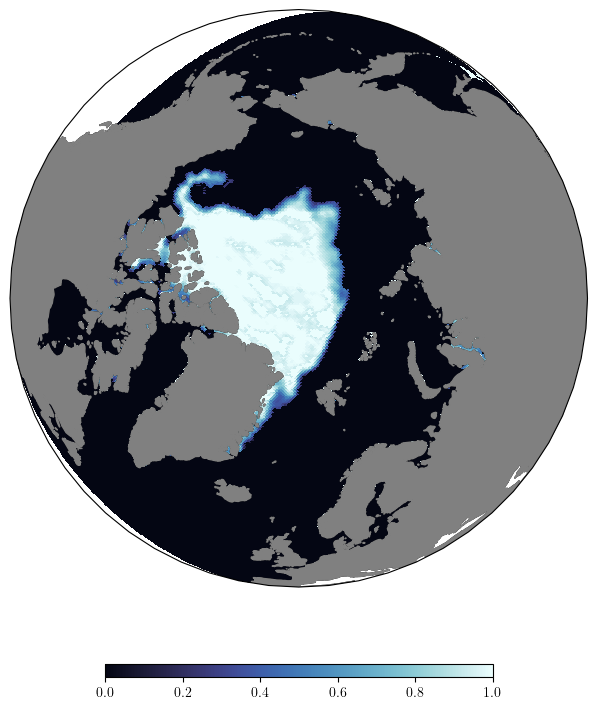

In [10]:
%time


name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(10,10))

cf = ax.pcolormesh(ds_nsidc.longitude, ds_nsidc.latitude, ds_nsidc.cdr_seaice_conc.sel(time='2020-09-15') ,  cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(land_50m, facecolor='grey')
# Draw the colorbar
cbar = fig.colorbar(cf, ax=ax, shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')


### Reading AVHRR data on albedo and SW flux

In [11]:
# %%time

# data_dir = '/glade/derecho/scratch/asiddiqui/data_files/AVHRR/'
# years = range(1982, 1983)  # 1982 to 2025

# all_daily_datasets = []

# for year in years:
#     print(f"Processing {year}...")
#     files = sorted(glob.glob(f"{data_dir}/{year}/*.nc"))
#     files = [f for f in files if "APP-X" in f]

#     times = []
#     for f in files:
#         basename = f.split('/')[-1]

#         # Extract date using regex: dYYYYMMDD
#         date_match = re.search(r'_d(\d{8})', basename)
#         if date_match is None:
#             raise ValueError(f"Could not parse date from filename: {basename}")
#         date_str = date_match.group(1)
#         date = pd.to_datetime(date_str, format='%Y%m%d')

#         # Extract overpass time: _0400_ or _1400_
#         time_match = re.search(r'_(\d{4})_', basename)
#         if time_match is None:
#             raise ValueError(f"Could not parse overpass time from filename: {basename}")
#         hour_minute = time_match.group(1)
#         hour = int(hour_minute[:2])
#         minute = int(hour_minute[2:])

#         dt = pd.Timestamp(year=date.year, month=date.month, day=date.day, hour=hour, minute=minute)
#         times.append(dt)
    
#     # Open all files for the year
#     ds_daily_avhrr = xr.open_mfdataset(
#         files,
#         combine='nested',
#         concat_dim='Time',
#         coords='minimal',
#         compat='override',
#         parallel=True,
#         chunks={'Time': 30}  # roughly monthly
#     )

#     # Assign proper Time coordinates
#     ds_daily_avhrr = ds_daily_avhrr.assign_coords(Time=times)

#     # # Keep only needed variables
#     vars_to_keep = ['cdr_surface_albedo', 'cdr_surface_downwelling_shortwave_flux', 'surface_type']
#     ds_daily_avhrr = ds_daily_avhrr[vars_to_keep]

#     # Compute daily mean by averaging both overpasses
#     ds_daily_avhrr = ds_daily_avhrr.groupby('Time.date').mean(dim='Time')
#     ds_daily_avhrr = ds_daily_avhrr.rename({'date': 'time'})
#     ds_daily_avhrr = ds_daily_avhrr.assign_coords(time=pd.to_datetime(ds_daily_avhrr['time']))

#     all_daily_datasets.append(ds_daily_avhrr)

# # Combine all years into a single dataset along the time dimension
# ds_avhrr = xr.concat(all_daily_datasets, dim='time')

# ds_avhrr

In [ ]:
# %%time

# data_dir = '/glade/derecho/scratch/asiddiqui/data_files/AVHRR/'
# years = range(1982, 2025)  # Example: 1982

# all_years = []

# for year in years:
#     print(f"Processing {year}...")
    
#     # --- Step 1: Filter APP-X files ---
#     files = sorted(glob.glob(f"{data_dir}/{year}/*.nc"))
#     files = [f for f in files if "APP-X" in f]
    
#     times = []
#     for f in files:
#         basename = f.split('/')[-1]

#         # Extract date
#         date_str = re.search(r'_d(\d{8})', basename).group(1)

#         # Extract overpass time
#         time_str = re.search(r'_(\d{4})_', basename).group(1)
#         dt = pd.Timestamp(
#             year=int(date_str[:4]),
#             month=int(date_str[4:6]),
#             day=int(date_str[6:]),
#             hour=int(time_str[:2]),
#             minute=int(time_str[2:])
#         )
#         times.append(dt)
    
#     # --- Step 2: Open all files lazily with Dask ---
#     ds = xr.open_mfdataset(
#         files,
#         combine='nested',
#         concat_dim='Time',
#         coords='minimal',
#         compat='override',
#         parallel=True
#     )

#     ds = ds.assign_coords(Time=times).sortby('Time')
    
#     # --- Step 3: Keep only the variables you want ---
#     vars_to_keep = ['cdr_surface_albedo', 'cdr_surface_downwelling_shortwave_flux', 'surface_type']
#     ds = ds[vars_to_keep]

#     ds = ds.chunk({'Time': 100})  # adjust x,y sizes based on your memory

#     # --- Step 4: Correct daily mean using intersection ---
#     daily_datasets = []
#     for day_val, group in ds.groupby('Time.date'):
#         # Only compute mean for days with 2 passes
#         if group.Time.size == 2:
#             morning = group.isel(Time=0)
#             afternoon = group.isel(Time=1)
#             mean_vars = {}
#             for var in group.data_vars:
#                 mask = (~morning[var].isnull()) & (~afternoon[var].isnull())
#                 mean_vars[var] = xr.concat([
#                     morning[var].where(mask),
#                     afternoon[var].where(mask)
#                 ], dim='Time').mean(dim='Time')
#             ds_day = xr.Dataset(mean_vars)
#             ds_day = ds_day.assign_coords(time=pd.Timestamp(day_val))
#             daily_datasets.append(ds_day)
#         # Skip days with <2 passes

#     # Concatenate daily datasets for the year
#     if daily_datasets:
#         ds_daily_year = xr.concat(daily_datasets, dim='time')
#         all_years.append(ds_daily_year)

# # --- Step 5: Combine all years ---
# ds_avhrr = xr.concat(all_years, dim='time')

# ds_avhrr


Processing 1982...


In [92]:
%%time


data_dir = '/glade/derecho/scratch/asiddiqui/data_files/AVHRR/'
years = range(1982, 2025)  # All years you want

all_years = []

# --- Gather all files once ---
all_files = sorted(glob.glob(f"{data_dir}/**/*.nc", recursive=True))
all_files = [f for f in all_files if "APP-X" in f]

def parse_time(fname):
    base = fname.split("/")[-1]
    d = re.search(r"_d(\d{8})", base).group(1)
    t = re.search(r"_(\d{4})_", base).group(1)
    return pd.Timestamp(f"{d[:4]}-{d[4:6]}-{d[6:]} {t[:2]}:{t[2:]}")

vars_to_keep = [
    "cdr_surface_albedo",
    "cdr_surface_downwelling_shortwave_flux",
    "surface_type",
]

for year in years:
    print(f"Processing {year}...")

    # --- Filter files by year in filename ---
    year_files = [f for f in all_files if re.search(r"_d" + str(year) + r"\d{4}", f)]
    if len(year_files) == 0:
        print(f"  No files for {year}, skipping.")
        continue

    # --- Parse times ---
    times = [parse_time(f) for f in year_files]

    # --- Open dataset lazily ---
    ds = xr.open_mfdataset(
        year_files,
        combine="nested",
        concat_dim="Time",
        engine="netcdf4",
        coords="minimal",
        data_vars="minimal",
        compat="override",
        parallel=True,
    )

    ds = ds.assign_coords(Time=("Time", times)).sortby("Time")
    ds = ds[vars_to_keep]
    ds = ds.chunk({"Time": 2})

    # --- Identify days with exactly 2 passes ---
    ds = ds.assign_coords(hour=ds["Time"].dt.hour)
    counts = ds["hour"].groupby("Time.date").count()
    valid_dates = counts.where(counts == 2, drop=True).date.values
    ds2 = ds.sel(Time=ds["Time"].dt.date.isin(valid_dates))

    # --- Pair morning & afternoon ---
    paired = ds2.groupby("Time.date").map(
        lambda g: g.sortby("Time").isel(Time=[0, 1]).assign_coords(pass_num=("Time",[0, 1]))
    )
    paired = paired.sortby("Time")

    # --- Compute intersection mask ---
    mask = (~xr.apply_ufunc(
        np.isnan,
        paired,
        dask="parallelized",
        output_dtypes=[bool]
    )).coarsen(Time=2, boundary="trim").all()

    masked = paired.where(mask.reindex(Time=paired["Time"], method="ffill"))

    # --- Compute daily mean ---
    ds_daily = masked.coarsen(Time=2, boundary="trim").mean()
    daily_times = masked["Time"][::2].values
    ds_daily = ds_daily.assign_coords(Time=("Time", daily_times)).rename({"Time": "time"})

    # --- Append to list ---
    all_years.append(ds_daily)

# --- Concatenate all years ---
if all_years:
    ds_avhrr = xr.concat(all_years, dim="time")
    print("All years concatenated:", ds_avhrr)
else:
    ds_avhrr = None
    print("No data found for any year.")

ds_avhrr

Processing 1982...
Processing 1983...
Processing 1984...
Processing 1985...
Processing 1986...
Processing 1987...
Processing 1988...
Processing 1989...
Processing 1990...
Processing 1991...
Processing 1992...
Processing 1993...
Processing 1994...
Processing 1995...
Processing 1996...
Processing 1997...
Processing 1998...
Processing 1999...
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
All years concatenated: <xarray.Dataset>
Dimensions:                                 (time: 15517, columns: 361,
                                             rows: 361)
Coordinates:
 

<xarray.Dataset>
Dimensions:                                 (time: 15517, columns: 361,
                                             rows: 361)
Coordinates:
    longitude                               (columns, rows) float32 -135.0 .....
    latitude                                (columns, rows) float32 29.75 ......
  * time                                    (time) datetime64[ns] 1982-01-01T...
Dimensions without coordinates: columns, rows
Data variables:
    cdr_surface_albedo                      (time, columns, rows) float32 dask.array<chunksize=(1, 361, 361), meta=np.ndarray>
    cdr_surface_downwelling_shortwave_flux  (time, columns, rows) float32 dask.array<chunksize=(1, 361, 361), meta=np.ndarray>
    surface_type                            (time, columns, rows) float32 dask.array<chunksize=(1, 361, 361), meta=np.ndarray>
Attributes: (12/28)
    Conventions:               CF-1.6, Unidata Dataset Discovery v1.0, NOAA C...
    standard_name_vocabulary:  CF Standard Name Table (v26, 08 November 2013)
    id:                        Polar-APP-X_v02r00_Nhem_0400_d19820101_c201906...
    nameing_authority:         gov.noaa.ncdc
    metadata_link:             https://doi.org/10.25921/AE96-0E57
    title:                     Extended AVHRR Polar Pathfinder Fundamental Cl...
    ...                        ...
    geospatial_lon_units:      degrees_east
    spatial_resolution:        25 km
    time_coverage_start:       1981-12-31T13:00:00Z
    time_coverage_end:         1982-01-01T19:00:00Z
    license:                   No restrictions on access or use
    summary:                   The Extended AVHRR Polar Pathfinder (APP-x) Ve...

In [93]:
ds_avhrr = ds_avhrr.chunk({'time':100})
ds_avhrr

<xarray.Dataset>
Dimensions:                                 (time: 15517, columns: 361,
                                             rows: 361)
Coordinates:
    longitude                               (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
    latitude                                (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
  * time                                    (time) datetime64[ns] 1982-01-01T...
Dimensions without coordinates: columns, rows
Data variables:
    cdr_surface_albedo                      (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
    cdr_surface_downwelling_shortwave_flux  (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
    surface_type                            (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
Attributes: (12/28)
    Conventions:               CF-1.6, Unidata Dataset Discovery v1.0, NOAA C...
    standard_name_vocabulary:  CF Standard Name Table (v26, 08 November 2013)
    id:                        Polar-APP-X_v02r00_Nhem_0400_d19820101_c201906...
    nameing_authority:         gov.noaa.ncdc
    metadata_link:             https://doi.org/10.25921/AE96-0E57
    title:                     Extended AVHRR Polar Pathfinder Fundamental Cl...
    ...                        ...
    geospatial_lon_units:      degrees_east
    spatial_resolution:        25 km
    time_coverage_start:       1981-12-31T13:00:00Z
    time_coverage_end:         1982-01-01T19:00:00Z
    license:                   No restrictions on access or use
    summary:                   The Extended AVHRR Polar Pathfinder (APP-x) Ve...

In [94]:
ds_avhrr.nbytes*1e-9

24.267458188000003

### Resample to monthly means

In [95]:
# Sea ice concentration between 0 and 1 (if present)
if 'cdr_seaice_conc' in ds_nsidc:
    ds_nsidc['cdr_seaice_conc'] = ds_nsidc['cdr_seaice_conc'].where(
        (ds_nsidc['cdr_seaice_conc'] >= 0) & (ds_nsidc['cdr_seaice_conc'] <= 1)
    )

# 2️⃣ Drop all-NaN time steps (days completely masked out)
ds_nsidc = ds_nsidc.dropna(dim='time', how='all')

# 3️⃣ Compute monthly means safely
ds_nsidc_monthly = ds_nsidc.resample(time='1M').mean(keep_attrs=True)

In [96]:
ds_nsidc_monthly.nbytes*1e-9
ds_nsidc_monthly

<xarray.Dataset>
Dimensions:          (time: 504, y: 448, x: 304)
Coordinates:
    xgrid            (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
    ygrid            (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    latitude         (y, x) float32 31.1 31.2 31.3 31.39 ... 34.68 34.58 34.47
    longitude        (y, x) float32 168.3 168.1 168.0 ... -10.36 -10.18 -9.999
  * time             (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2023-12-31
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 dask.array<chunksize=(6, 448, 304), meta=np.ndarray>
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

In [97]:
ds_nsidc_monthly = ds_nsidc_monthly.load()

In [104]:
# Sea ice concentration between 0 and 1 (if present)
if 'cdr_surface_albedo' in ds_avhrr:
    ds_avhrr['cdr_surface_albedo'] = ds_avhrr['cdr_surface_albedo'].where(
        (ds_avhrr['cdr_surface_albedo'] >= 0) & (ds_avhrr['cdr_surface_albedo'] <= 1)
    )


# 3️⃣ Compute monthly means safely
ds_avhrr_monthly = ds_avhrr.resample(time='1M').mean(skipna=True)
ds_avhrr_monthly

<xarray.Dataset>
Dimensions:                                 (time: 516, columns: 361, rows: 361)
Coordinates:
    longitude                               (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
    latitude                                (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
  * time                                    (time) datetime64[ns] 1982-01-31 ...
Dimensions without coordinates: columns, rows
Data variables:
    cdr_surface_albedo                      (time, columns, rows) float32 dask.array<chunksize=(6, 361, 361), meta=np.ndarray>
    cdr_surface_downwelling_shortwave_flux  (time, columns, rows) float32 dask.array<chunksize=(6, 361, 361), meta=np.ndarray>
    surface_type                            (time, columns, rows) float32 dask.array<chunksize=(6, 361, 361), meta=np.ndarray>
Attributes: (12/28)
    Conventions:               CF-1.6, Unidata Dataset Discovery v1.0, NOAA C...
    standard_name_vocabulary:  CF Standard Name Table (v26, 08 November 2013)
    id:                        Polar-APP-X_v02r00_Nhem_0400_d19820101_c201906...
    nameing_authority:         gov.noaa.ncdc
    metadata_link:             https://doi.org/10.25921/AE96-0E57
    title:                     Extended AVHRR Polar Pathfinder Fundamental Cl...
    ...                        ...
    geospatial_lon_units:      degrees_east
    spatial_resolution:        25 km
    time_coverage_start:       1981-12-31T13:00:00Z
    time_coverage_end:         1982-01-01T19:00:00Z
    license:                   No restrictions on access or use
    summary:                   The Extended AVHRR Polar Pathfinder (APP-x) Ve...

In [105]:
ds_avhrr_monthly.nbytes*1e-9

0.807994328

In [106]:
ds_avhrr_monthly = ds_avhrr_monthly.chunk({'time':100})
ds_avhrr_monthly

<xarray.Dataset>
Dimensions:                                 (time: 516, columns: 361, rows: 361)
Coordinates:
    longitude                               (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
    latitude                                (columns, rows) float32 dask.array<chunksize=(361, 361), meta=np.ndarray>
  * time                                    (time) datetime64[ns] 1982-01-31 ...
Dimensions without coordinates: columns, rows
Data variables:
    cdr_surface_albedo                      (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
    cdr_surface_downwelling_shortwave_flux  (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
    surface_type                            (time, columns, rows) float32 dask.array<chunksize=(100, 361, 361), meta=np.ndarray>
Attributes: (12/28)
    Conventions:               CF-1.6, Unidata Dataset Discovery v1.0, NOAA C...
    standard_name_vocabulary:  CF Standard Name Table (v26, 08 November 2013)
    id:                        Polar-APP-X_v02r00_Nhem_0400_d19820101_c201906...
    nameing_authority:         gov.noaa.ncdc
    metadata_link:             https://doi.org/10.25921/AE96-0E57
    title:                     Extended AVHRR Polar Pathfinder Fundamental Cl...
    ...                        ...
    geospatial_lon_units:      degrees_east
    spatial_resolution:        25 km
    time_coverage_start:       1981-12-31T13:00:00Z
    time_coverage_end:         1982-01-01T19:00:00Z
    license:                   No restrictions on access or use
    summary:                   The Extended AVHRR Polar Pathfinder (APP-x) Ve...

In [107]:
ds_avhrr_monthly = ds_avhrr_monthly.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 158.96 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [108]:
ds_avhrr_monthly

<xarray.Dataset>
Dimensions:                                 (time: 516, columns: 361, rows: 361)
Coordinates:
    longitude                               (columns, rows) float32 -135.0 .....
    latitude                                (columns, rows) float32 29.75 ......
  * time                                    (time) datetime64[ns] 1982-01-31 ...
Dimensions without coordinates: columns, rows
Data variables:
    cdr_surface_albedo                      (time, columns, rows) float32 nan...
    cdr_surface_downwelling_shortwave_flux  (time, columns, rows) float32 nan...
    surface_type                            (time, columns, rows) float32 0.0...
Attributes: (12/28)
    Conventions:               CF-1.6, Unidata Dataset Discovery v1.0, NOAA C...
    standard_name_vocabulary:  CF Standard Name Table (v26, 08 November 2013)
    id:                        Polar-APP-X_v02r00_Nhem_0400_d19820101_c201906...
    nameing_authority:         gov.noaa.ncdc
    metadata_link:             https://doi.org/10.25921/AE96-0E57
    title:                     Extended AVHRR Polar Pathfinder Fundamental Cl...
    ...                        ...
    geospatial_lon_units:      degrees_east
    spatial_resolution:        25 km
    time_coverage_start:       1981-12-31T13:00:00Z
    time_coverage_end:         1982-01-01T19:00:00Z
    license:                   No restrictions on access or use
    summary:                   The Extended AVHRR Polar Pathfinder (APP-x) Ve...

In [109]:
A = ds_avhrr_monthly.cdr_surface_downwelling_shortwave_flux.sel(time='2002-06-30').squeeze()
B = ds_avhrr_monthly.cdr_surface_downwelling_shortwave_flux.sel(time='2002-07-31').squeeze()

diff = A-B

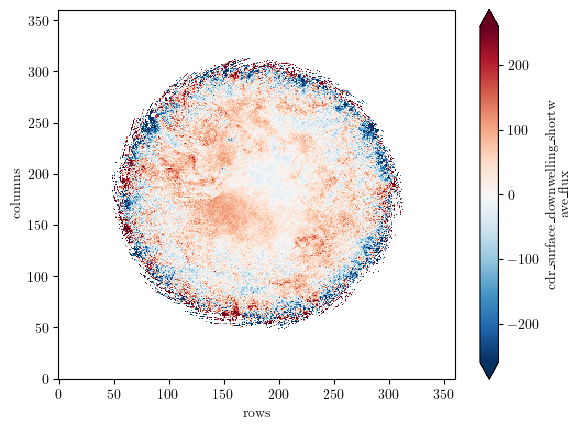

In [110]:
diff.plot(robust=True)

### Regridding the data

In [111]:
vars_to_keep = ['cdr_surface_albedo', 'cdr_surface_downwelling_shortwave_flux']

# Target grid (NSIDC)
target_grid = {
    "lon": ds_nsidc_monthly["longitude"],
    "lat": ds_nsidc_monthly["latitude"]
}


# --- Create the regridder (compute weights the first time) ---
regridder = xe.Regridder(
    ds_avhrr_monthly,
    target_grid,
    method="bilinear",
    reuse_weights=False      # compute new weights
)

# --- Apply regridding ---
ds_avhrr_re = xr.Dataset()
for v in vars_to_keep:
    ds_avhrr_re[v] = regridder(ds_avhrr_monthly[v])

# --- Align coordinates with NSIDC ---
ds_avhrr_re = ds_avhrr_re.assign_coords(
    latitude=ds_nsidc["latitude"],
    longitude=ds_nsidc["longitude"]
)


### Matching the time dimension with nsdic data

In [112]:
ds_avhrr_re = ds_avhrr_re.sel(time=slice('1982-01','2023-12'))
ds_avhrr_re

<xarray.Dataset>
Dimensions:                                 (time: 504, x: 304, y: 448)
Coordinates:
  * time                                    (time) datetime64[ns] 1982-01-31 ...
    xgrid                                   (x) float32 -3.838e+06 ... 3.738e+06
    ygrid                                   (y) float32 5.838e+06 ... -5.338e+06
    longitude                               (y, x) float32 168.3 ... -9.999
    latitude                                (y, x) float32 31.1 31.2 ... 34.47
Dimensions without coordinates: x, y
Data variables:
    cdr_surface_albedo                      (time, y, x) float32 0.0 0.0 ... 0.0
    cdr_surface_downwelling_shortwave_flux  (time, y, x) float32 0.0 0.0 ... 0.0

### Compute sea ice area

In [113]:
ds_nsidc_monthly = ds_nsidc_monthly.sel(time=slice('1982-01','2023-12'))
ds_nsidc_monthly

<xarray.Dataset>
Dimensions:          (time: 504, y: 448, x: 304)
Coordinates:
    xgrid            (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
    ygrid            (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    latitude         (y, x) float32 31.1 31.2 31.3 31.39 ... 34.68 34.58 34.47
    longitude        (y, x) float32 168.3 168.1 168.0 ... -10.36 -10.18 -9.999
  * time             (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2023-12-31
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

In [114]:
# assume your dataset is called ds
sic = ds_nsidc_monthly['cdr_seaice_conc']

# 1️⃣ Compute grid spacing (in meters)
dx = np.abs(ds_nsidc.xgrid.diff('x').mean().item())
dy = np.abs(ds_nsidc.ygrid.diff('y').mean().item())

print(f"Grid spacing: dx={dx:.1f} m, dy={dy:.1f} m")

# 2️⃣ Compute grid cell area
cell_area = dx * dy  # in m²

# 3️⃣ Convert SIC to fraction and mask invalid values
sic = sic.where((sic >= 0) & (sic <= 1))

# 4️⃣ Compute total ice-covered area (sum over spatial dims)
seaice_area = (sic * cell_area).sum(dim=['y', 'x'])

# 5️⃣ Convert to million km²
seaice_area_mkm2 = (seaice_area / 1e6) / 1e6
seaice_area_mkm2.name = 'seaice_area_million_km2'

seaice_area_mkm2


Grid spacing: dx=25000.0 m, dy=25000.0 m


<xarray.DataArray 'seaice_area_million_km2' (time: 504)>
array([14.357784 , 15.229325 , 15.333651 , 14.696651 , 13.028858 ,
       11.238289 ,  9.086908 ,  7.150245 ,  6.5719113,  8.528151 ,
       10.716951 , 12.802279 , 14.183435 , 15.326203 , 15.390678 ,
       14.31971  , 12.676829 , 11.243634 ,  9.282406 ,  7.1205754,
        6.6951466,  8.461545 , 10.644109 , 12.525851 , 13.794404 ,
       14.62881  , 14.931125 , 14.280511 , 12.724091 , 11.043801 ,
        9.954865 ,  6.786808 ,  6.2575717,  7.822828 , 10.103151 ,
       12.258008 , 13.999429 , 14.784889 , 15.164168 , 14.631366 ,
       13.151634 , 10.951542 ,  8.588674 ,  6.6229486,  6.2051263,
        7.835447 , 10.163872 , 12.225819 , 14.056534 , 15.056565 ,
       15.268181 , 14.174503 , 12.57776  , 10.956604 ,  8.958849 ,
        7.022235 ,  6.7323804,  8.609281 , 10.64711  , 12.635411 ,
       14.243187 , 15.411266 , 15.13396  , 14.475284 , 12.881741 ,
       11.279954 ,  9.006187 ,  6.6150823,  6.64691  ,  8.392435 ,
       10.470487 , 11.778221 , 14.444319 , 15.034075 , 15.353824 ,
       14.286598 , 12.500557 , 10.617688 ,  8.525428 ,  6.8211584,
        6.6551237,  8.470317 , 10.576711 , 12.859892 , 14.24518  ,
       14.767537 , 14.577373 , 13.383322 , 12.124146 , 10.882982 ,
        8.692572 ,  6.7153344,  6.1783366,  8.134963 , 10.34716  ,
       12.629307 , 14.080481 , 14.967041 , 15.137852 , 13.62685  ,
...
        6.2143617,  9.039297 , 11.167655 , 12.622088 , 13.395861 ,
       13.583724 , 12.647325 , 10.794578 ,  8.936532 ,  6.5875425,
        4.2216935,  3.7469013,  5.3604803,  7.8577933, 10.503803 ,
       12.303619 , 13.226005 , 13.390227 , 12.779701 , 11.505532 ,
        9.131834 ,  6.627928 ,  4.532724 ,  4.1587024,  6.0436296,
        8.633661 , 10.847418 , 12.284145 , 13.130875 , 13.471332 ,
       12.76528  , 11.190184 ,  9.422541 ,  6.8292394,  4.5902085,
        4.080977 ,  5.451518 ,  9.022278 , 11.007921 , 12.768998 ,
       13.593025 , 13.693331 , 12.422421 , 11.021101 ,  9.017189 ,
        6.1533403,  4.07236  ,  3.7347882,  5.068606 ,  8.495116 ,
       11.05453  , 12.835124 , 13.819161 , 13.811882 , 12.636393 ,
       11.15012  ,  9.106302 ,  6.0695515,  3.9834945,  3.394357 ,
        4.682589 ,  8.144901 , 10.812484 , 12.603094 , 13.551784 ,
       13.782662 , 12.783917 , 11.461223 ,  9.196239 ,  6.522716 ,
        4.6425867,  4.186038 ,  6.098336 ,  9.022788 , 11.255107 ,
       13.012026 , 13.742589 , 13.650334 , 13.041491 , 11.697157 ,
        9.289047 ,  6.9810104,  4.8651414,  4.1826167,  5.924461 ,
        8.944555 , 10.983413 , 12.53129  , 13.423236 , 13.592119 ,
       13.03521  , 11.678223 ,  9.369314 ,  6.7644563,  4.3269143,
        3.6266103,  5.661831 ,  8.822813 , 11.008431 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2023-12-31

In [115]:
# --- 4. Remove negative or unrealistic values ---
# Example: below 0 or above 20 million km² (Arctic typical range ~0–15)
seaice_area_mkm2 = seaice_area_mkm2.where(
    (seaice_area_mkm2 >= 2) & (seaice_area_mkm2 <= 20)
)

# --- 5. (Optional) Remove statistical outliers ---
# Compute z-scores to remove isolated spikes
z = (seaice_area_mkm2 - seaice_area_mkm2.mean()) / seaice_area_mkm2.std()
seaice_area_mkm2 = seaice_area_mkm2.where(np.abs(z) < 3)



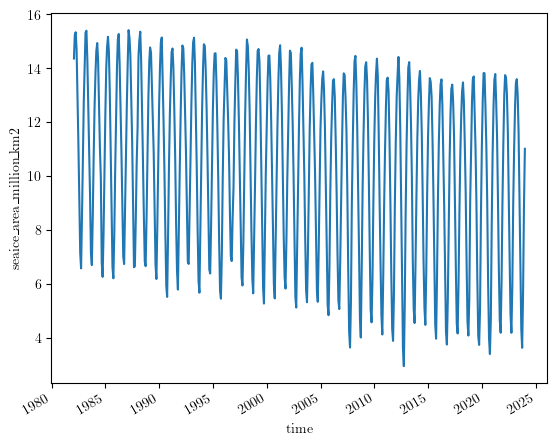

In [116]:
seaice_area_mkm2.plot()

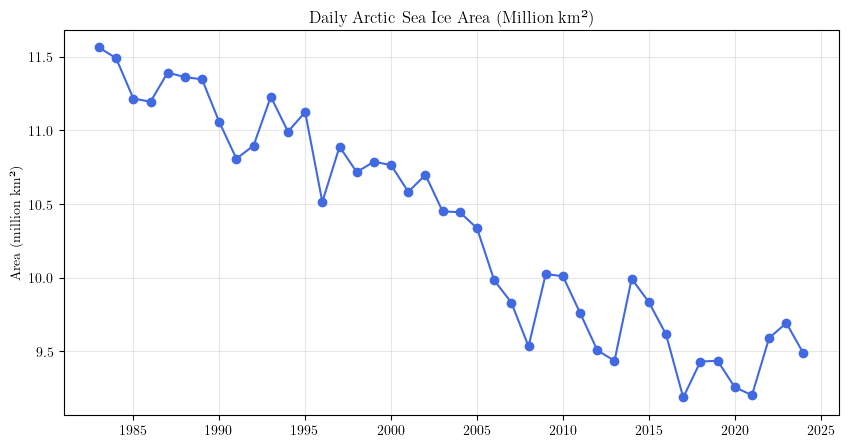

In [117]:
# --- 6. Plot cleaned data ---
fig, ax = plt.subplots(figsize=(10,5))
      
plt.plot(seaice_area_mkm2.resample(time="1Y").mean().time, seaice_area_mkm2.resample(time="1Y").mean(), '-o', color='royalblue')
plt.title('Daily Arctic Sea Ice Area (Million km²)')
plt.ylabel('Area (million km²)')
plt.grid(alpha=0.3)
plt.show()

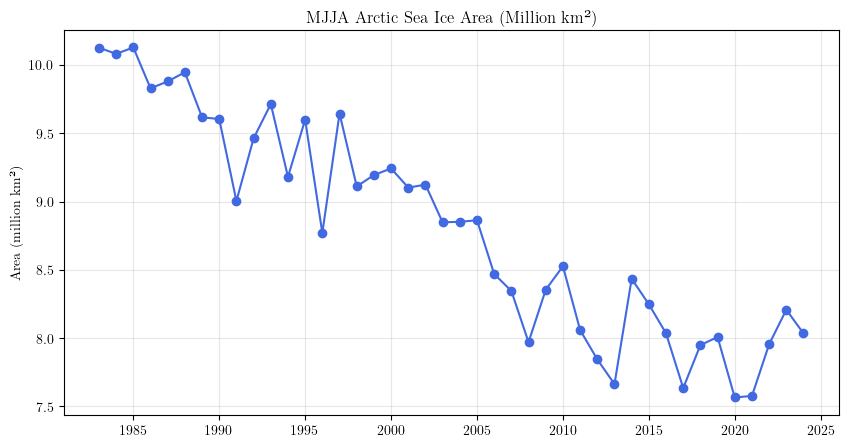

In [118]:
# --- Select only May–August (MJJA) ---
mjja_sia = seaice_area_mkm2.sel(time=seaice_area_mkm2['time'].dt.month.isin([5, 6, 7, 8]))

# --- Compute MJJA mean per year ---
mjja_mean_sia = mjja_sia.resample(time="1Y").mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    mjja_mean_sia['time'],
    mjja_mean_sia,
    '-o',
    color='royalblue',
    label='MJJA mean'
)

ax.set_title('MJJA Arctic Sea Ice Area (Million km²)')
ax.set_ylabel('Area (million km²)')
ax.grid(alpha=0.3)
plt.show()


Saving the sea ice area and avhrr data

In [119]:
# seaice_area_mkm2.to_netcdf('../data_files/NSIDC_sia_monthly.nc')

In [120]:
ds_avhrr_re.to_netcdf('../data_files/avhrr_monthly_means.nc')